# Personal Knowledge Decay Predictor

# Notebook 03
## Interaction and Sequence Analysis

### Objective
Validate repeated Student–Skill interactions and prepare ordered sequences for target engineering.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
from pathlib import Path

PROJECT_NAME = "Personal Knowledge Decay Predictor"

matches = [
    p for p in Path("/content/drive/MyDrive").rglob(PROJECT_NAME)
    if p.is_dir()
]

PROJECT_ROOT = matches[0]

sys.path.append(str(PROJECT_ROOT))

from config import *

✅ Project Root : /content/drive/MyDrive/Personal Knowledge Decay Predictor


🟦 Step 2 — Load Dataset

In [3]:
import pandas as pd
df = pd.read_csv(
    f"{DATA_DIR}/Processed/cleaned_dataset.csv",
    low_memory=False
)

print(df.shape)

(942816, 77)


## Dataset Overview

The cleaned interaction dataset is loaded from Notebook 02.

This notebook validates whether repeated Student–Skill interactions exist and prepares ordered learning sequences for the subsequent target engineering stage.

In [4]:
print("StartTime")

print(df["startTime"].head(10))

print("\nEndTime")

print(df["endTime"].head(10))

print("\nTimeTaken")

print(df["timeTaken"].head(10))

StartTime
0    1096470301
1    1096470350
2    1096470354
3    1096470360
4    1096470378
5    1096470380
6    1096470439
7    1096470454
8    1096470515
9    1096470533
Name: startTime, dtype: int64

EndTime
0    1096470350
1    1096470354
2    1096470360
3    1096470378
4    1096470380
5    1096470439
6    1096470454
7    1096470515
8    1096470533
9    1096470533
Name: endTime, dtype: int64

TimeTaken
0    49.0
1     4.0
2     6.0
3    18.0
4     2.0
5    59.0
6    15.0
7    61.0
8    18.0
9     0.0
Name: timeTaken, dtype: float64


In [5]:
print(df["startTime"].dtype)

print(df["endTime"].dtype)

print(df["timeTaken"].dtype)

int64
int64
float64


🟦 Step 3 — Check Timestamp Columns

In [6]:
time_columns = [
    col for col in df.columns
    if "time" in col.lower()
]

print("Temporal Features")
print("="*40)

for col in time_columns:
    print(col)

Temporal Features
startTime
endTime
timeTaken
totalFrTimeOnSkill
timeSinceSkill
frTimeTakenOnScaffolding
timeGreater5Secprev2wrong
timeGreater10SecAndNextActionRight
sumTime3SDWhen3RowRight
sumTimePerSkill
totalTimeByPercentCorrectForskill
timeOver80


🟦 Step 4
## Student × Skill Sequence Validation

Knowledge decay can only be modeled if students repeatedly practice the same skill.

Therefore, we verify whether the dataset contains repeated Student–Skill interactions.

In [7]:
student_skill = (
    df.groupby(["studentId", "skill"])
      .size()
      .reset_index(name="interaction_count")
)

student_skill.head()

,studentId,skill,interaction_count
0,8,addition,20
1,8,algebraic-manipulation,12
2,8,application: compare expressions,7
3,8,application: compare points,19
4,8,application: find slope in graph,2


In [8]:
student_skill["interaction_count"].describe()

,interaction_count
count,71202.000000
mean,13.241426
std,20.089270
min,1.000000
25%,2.000000
50%,7.000000
75%,16.000000
max,745.000000


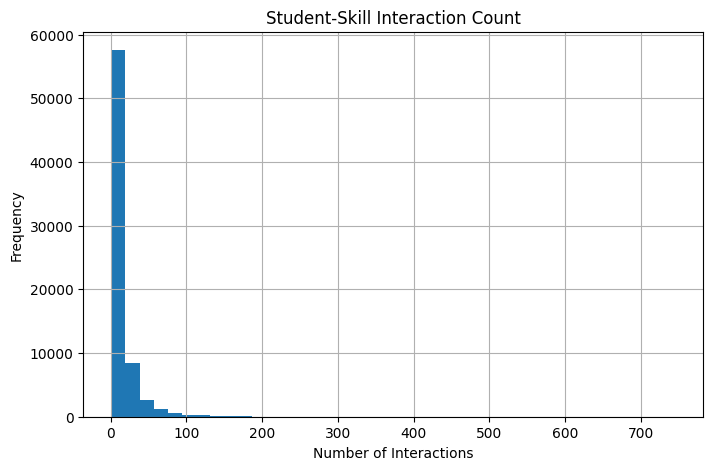

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

student_skill["interaction_count"].hist(bins=40)

plt.title("Student-Skill Interaction Count")

plt.xlabel("Number of Interactions")

plt.ylabel("Frequency")

plt.show()

In [10]:
sequence_length = (
    df.groupby(["studentId","skill"])
      .size()
)

sequence_length.describe()

,0
count,71202.000000
mean,13.241426
std,20.089270
min,1.000000
25%,2.000000
50%,7.000000
75%,16.000000
max,745.000000


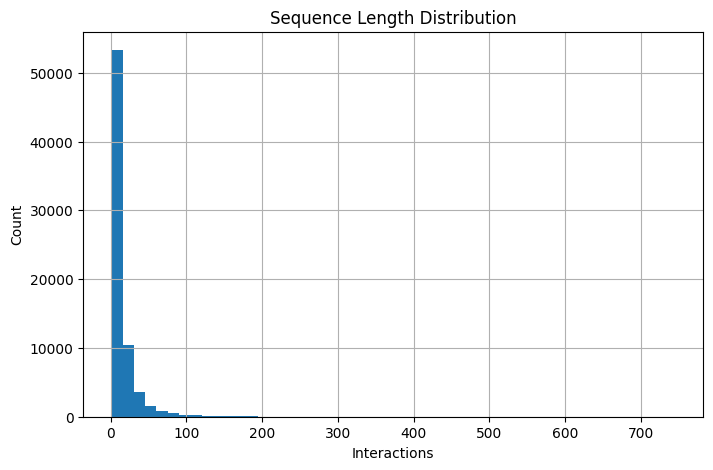

In [11]:
plt.figure(figsize=(8,5))

sequence_length.hist(bins=50)

plt.title("Sequence Length Distribution")

plt.xlabel("Interactions")

plt.ylabel("Count")

plt.show()

🟦 Step 5 :- Interaction Order

Instead of using calendar dates, we can use interaction order.

In [12]:
df = df.sort_values(
    ["studentId", "skill", "action_num"]
)

df["interaction_order"] = (
    df.groupby(["studentId", "skill"])
      .cumcount() + 1
)

In [13]:
df[
    ["studentId","skill","interaction_order"]
].head(20)

,studentId,skill,interaction_order
208,8,addition,1
211,8,addition,2
222,8,addition,3
229,8,addition,4
247,8,addition,5
248,8,addition,6
249,8,addition,7
251,8,addition,8
252,8,addition,9
253,8,addition,10


In [14]:
sequence_summary = (
    df.groupby(["studentId","skill"])
      .agg(
          first_interaction=("interaction_order","min"),
          last_interaction=("interaction_order","max"),
          total_interactions=("interaction_order","count")
      )
)

sequence_summary.head()

first_interaction  \
studentId skill                                                 
8         addition                                          1   
          algebraic-manipulation                            1   
          application: compare expressions                  1   
          application: compare points                       1   
          application: find slope in graph                  1   

                                            last_interaction  \
studentId skill                                                
8         addition                                        20   
          algebraic-manipulation                          12   
          application: compare expressions                 7   
          application: compare points                     19   
          application: find slope in graph                 2   

                                            total_interactions  
studentId skill                                                 
8         addition                                          20  
          algebraic-manipulation                            12  
          application: compare expressions                   7  
          application: compare points                       19  
          application: find slope in graph                   2

In [15]:
sequence_summary.describe()

,first_interaction,last_interaction,total_interactions
count,71202.0,71202.000000,71202.000000
mean,1.0,13.241426,13.241426
std,0.0,20.089270,20.089270
min,1.0,1.000000,1.000000
25%,1.0,2.000000,2.000000
50%,1.0,7.000000,7.000000
75%,1.0,16.000000,16.000000
max,1.0,745.000000,745.000000


🟦 Step 6 — Student Timeline
How many interactions per student?

In [16]:
student_activity = (

    df.groupby("studentId")

      .size()

      .sort_values(
          ascending=False
      )

)

student_activity.describe()

,0
count,1709.000000
mean,551.677004
std,419.084504
min,2.000000
25%,238.000000
50%,441.000000
75%,739.000000
max,3057.000000


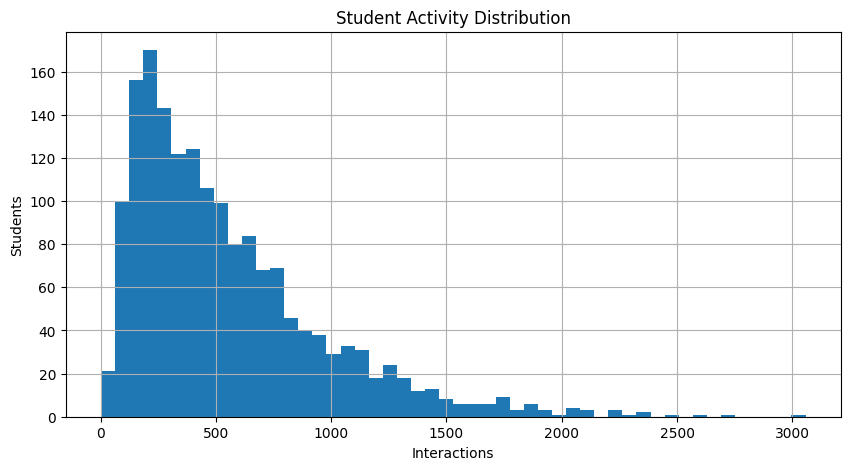

In [17]:
plt.figure(figsize=(10,5))

student_activity.hist(bins=50)

plt.title("Student Activity Distribution")

plt.xlabel("Interactions")

plt.ylabel("Students")

plt.show()

🟦 Step 7 — Skill Timeline

In [18]:
skill_activity = (

    df.groupby("skill")

      .size()

      .sort_values(
          ascending=False
      )

)

skill_activity.describe()

,0
count,102.000000
mean,9243.294118
std,12960.805962
min,2.000000
25%,1034.000000
50%,4765.000000
75%,13554.500000
max,78103.000000


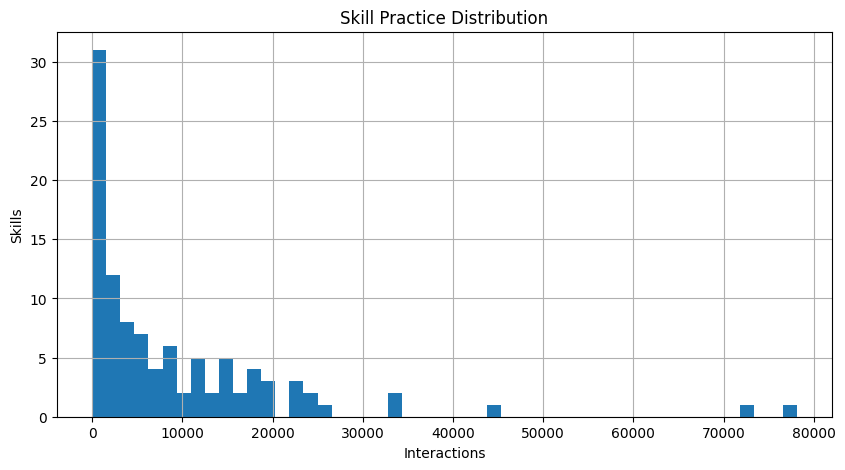

In [19]:
plt.figure(figsize=(10,5))

skill_activity.hist(bins=50)

plt.title("Skill Practice Distribution")

plt.xlabel("Interactions")

plt.ylabel("Skills")

plt.show()

## Save Sequence Ready Dataset

In [20]:
import os

print(os.getcwd())

/content/drive/.shortcut-targets-by-id/1LWX90DlmGF9QpN_sG10QqlUaqgqBZdLn/Personal Knowledge Decay Predictor


In [21]:
os.makedirs("Data/Processed", exist_ok=True)

df.to_csv("Data/Processed/sequence_ready_dataset.csv", index=False)
print("sequence_ready_dataset.csv saved successfully")

sequence_ready_dataset.csv saved successfully


# Conclusion

Key findings:

- The dataset contains repeated Student–Skill interactions.
- Students practice skills multiple times.
- Interaction sequences are sufficiently long for temporal modeling.
- Ordered interaction histories have been successfully created.
- The processed dataset has been saved for target engineering.

Next Notebook:

Notebook 04 – Target Engineering